# Tarea 2
## Jorge Moreno 

- Objetivo principal: Implementar algoritmos de diferencias finitas para resolver ecuaciones
hiperbólicas (lineales y no lineales) evaluando su estabilidad, difusión numérica y sentido
causal.

-  Resultados esperados: Contrastar cuantitativamente los esquemas de resolución en tér-
minos de estabilidad, conservación de la forma de onda y costo computacional. Demostrar
entendimiento de todo lo implementado

Ecuación de advección lineal
Considere la ecuación hiperbólica de transporte unidireccional de una cantidad escalar u(x,t) a una
velocidad constante c: 

$\frac{∂u}{∂t} + c \frac{∂u}{∂x}= 0 $


Considere un dominio espacial periódico $x∈[0,L]$ con $ L= 10.0$ y velocidad $ c= 1.0 $. Defina una
condición inicial de perfil cuadrado: $ u(x,0) = 1.0 $ para $x∈[4.0,6.0]$, y $ u(x,0) = 0.0 $ en el resto del
dominio.

1. Discretice el dominio con N= 200 puntos espaciales. Implemente el método FTCS (For-
ward in Time, Centered in Space) e integre el sistema. Documente lo que ocurre y explique
teóricamente el resultado (por ejemplo, basándose en el análisis del factor de amplificación).

2. Implemente el método de Lax y el método Upwind. Simule el sistema hasta t= 15.0
utilizando un número de Courant ν= 0.8.
1

3. Grafique la solución analítica exacta superpuesta con las soluciones obtenidas por Lax y
Upwind. Estudio el error cometido respecto a la solución analítica para ambos métodos.

4. Repita la simulación variando el número de Courant (ej., ν= 0.5,0.8,1.0). Discuta de forma
detallada cómo afecta la elección de νa la viscosidad artificial en el método de Lax y al
comportamiento general de la solución en el método Upwind.

In [69]:
"""
Importanto las mismas librerias usadas en el notebook de la classe 6 para 
hacer gráficos interactivos 

"""


%matplotlib inline
#%config InlineBackend.figure_format = 'svg'
%config InlineBackend.figure_format = 'retina'

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import matplotlib.animation as animation
from IPython.display import HTML


### Análisis Teórico: Inestabilidad del Esquema FTCS

**Observación de la simulación:**
Al ejecutar el esquema numérico FTCS, la solución desarrolla oscilaciones extremas (ruido de alta frecuencia) que destruyen por completo el perfil cuadrado inicial de la onda. Si la simulación avanza en el tiempo, los valores crecen exponencialmente produciendo un desbordamiento numérico (`overflow`).

**Análisis del Factor de Amplificación (Von Neumann):**
La ecuación discretizada mediante el esquema FTCS (Forward in Time, Centered in Space) para la advección lineal con número de Courant $\nu = c \frac{\Delta t}{\Delta x}$ es:

$$u_j^{n+1} = u_j^n - \frac{\nu}{2} (u_{j+1}^n - u_{j-1}^n)$$

Para realizar el análisis de estabilidad de Von Neumann, introducimos un modo de Fourier discreto $u_j^n = G^n e^{i k j \Delta x}$, donde $G$ es el factor de amplificación de la amplitud y $k$ el número de onda. Sustituyendo en el esquema numérico:

$$G^{n+1} e^{i k j \Delta x} = G^n e^{i k j \Delta x} - \frac{\nu}{2} \left( G^n e^{i k (j+1) \Delta x} - G^n e^{i k (j-1) \Delta x} \right)$$

Dividiendo por $G^n e^{i k j \Delta x}$ obtenemos el factor de amplificación $G$:

$$G = 1 - \frac{\nu}{2} \left( e^{i k \Delta x} - e^{-i k \Delta x} \right)$$

Aplicando la identidad de Euler $\sin(\theta) = \frac{e^{i \theta} - e^{-i \theta}}{2i}$, la expresión se simplifica a:

$$G = 1 - i \nu \sin(k \Delta x)$$

Para que un método explícito sea numéricamente estable, se requiere $\vert{}G\vert{} \le 1$. Calculando el módulo al cuadrado:

$$\vert{}G\vert{}^2 = 1^2 + (-\nu \sin(k \Delta x))^2 = 1 + \nu^2 \sin^2(k \Delta x)$$

Dado que el término $\nu^2 \sin^2(k \Delta x)$ es estrictamente mayor que cero para cualquier modo espacial ($k \neq 0$), se concluye que **$\vert{}G\vert{} > 1$ en todo momento**. Esto demuestra que el esquema FTCS es **incondicionalmente inestable** para la ecuación de advección pura; cualquier error de truncamiento se amplifica exponencialmente.

---

### Análisis Numérico: Métodos de Lax y Upwind

**Comparación de los esquemas en $t=15.0$:**

* **Método de Lax (Difusión Numérica):** Para lograr la estabilidad, el método de Lax introduce un término de difusión numérica (viscosidad artificial) en la ecuación original. La magnitud de esta disipación es proporcional a $(1 - \nu^2)$. Cuando $\nu = 0.5$, la difusión es máxima, achatando y esparciendo severamente la onda cuadrada. Al aumentar a $\nu = 0.8$, la disipación se reduce, pero sigue deformando las esquinas del pulso.


* **Método Upwind (Sentido Causal):** El esquema Upwind mantiene el sentido causal de la onda tomando información "aguas arriba" (en este caso, del nodo $i-1$ ya que $c>0$). Su término disipativo es proporcional a $(1 - \nu)$. Por esto, para $\nu = 0.5$ y $\nu = 0.8$, Upwind preserva de forma significativamente superior la amplitud y la forma rectangular del pulso frente al método de Lax. Esto se comprueba cuantitativamente al observar un menor error RMSE.


* **El caso óptimo $\nu = 1.0$:** Cuando $\nu = 1.0$, los términos de viscosidad artificial de ambos métodos se anulan. Esto se conoce como el "número de Courant mágico" para advección pura: la información se traslada exactamente un nodo $\Delta x$ por cada paso $\Delta t$, logrando que la solución discreta coincida a la perfección con la analítica.



---

### Análisis Físico: Ecuación de Cuerda No Lineal

**Comportamiento ante diferentes amplitudes y tiempos:**

* **Efecto de la amplitud ($A$):** Para amplitudes pequeñas ($A=0.1$), el término no lineal es despreciable, por lo que las soluciones del modelo lineal y no lineal se superponen casi perfectamente en todo momento. Para amplitudes grandes ($A=1.0$), el término no lineal domina la dinámica y el comportamiento del sistema difiere drásticamente del caso lineal.


* **Evolución temporal ($t$):** La condición inicial gaussiana se divide en dos pulsos que viajan en direcciones opuestas. En el sistema lineal, los pulsos mantienen su simetría gaussiana de forma indefinida. En el sistema no lineal con $A=1.0$, los pulsos pierden su simetría con el paso del tiempo, deformándose estructuralmente a medida que se propagan.



**Explicación Física de la Deformación:**
En la ecuación de onda no lineal, la velocidad de propagación no es constante, sino que depende de una "velocidad efectiva" local $c_{eff}$:

$$c_{eff} = c \left[ 1 + \left(\frac{\partial y}{\partial x}\right)^2 \right]^{-1/4}$$

Esta velocidad efectiva es dependiente de la pendiente local de la cuerda $\frac{\partial y}{\partial x}$.

* **En la cresta de la onda**, la pendiente es nula ($\frac{\partial y}{\partial x} = 0$), por lo que la velocidad local es máxima e igual a $c$.


* **En los flancos de la onda**, la pendiente es distinta de cero ($\vert{}\frac{\partial y}{\partial x}\vert{} > 0$), lo que hace que el término entre corchetes sea menor que $1$. En consecuencia, **los flancos viajan a una velocidad menor que la cresta ($c_{eff} < c$)**.



Físicamente, esto significa que la cresta de la onda avanza más rápido que la base. Como resultado, la parte superior "alcanza" a la parte inferior delantera, provocando que la onda se incline y se empine asimétricamente hacia adelante (un fenómeno análogo a cómo rompen las olas en la costa).

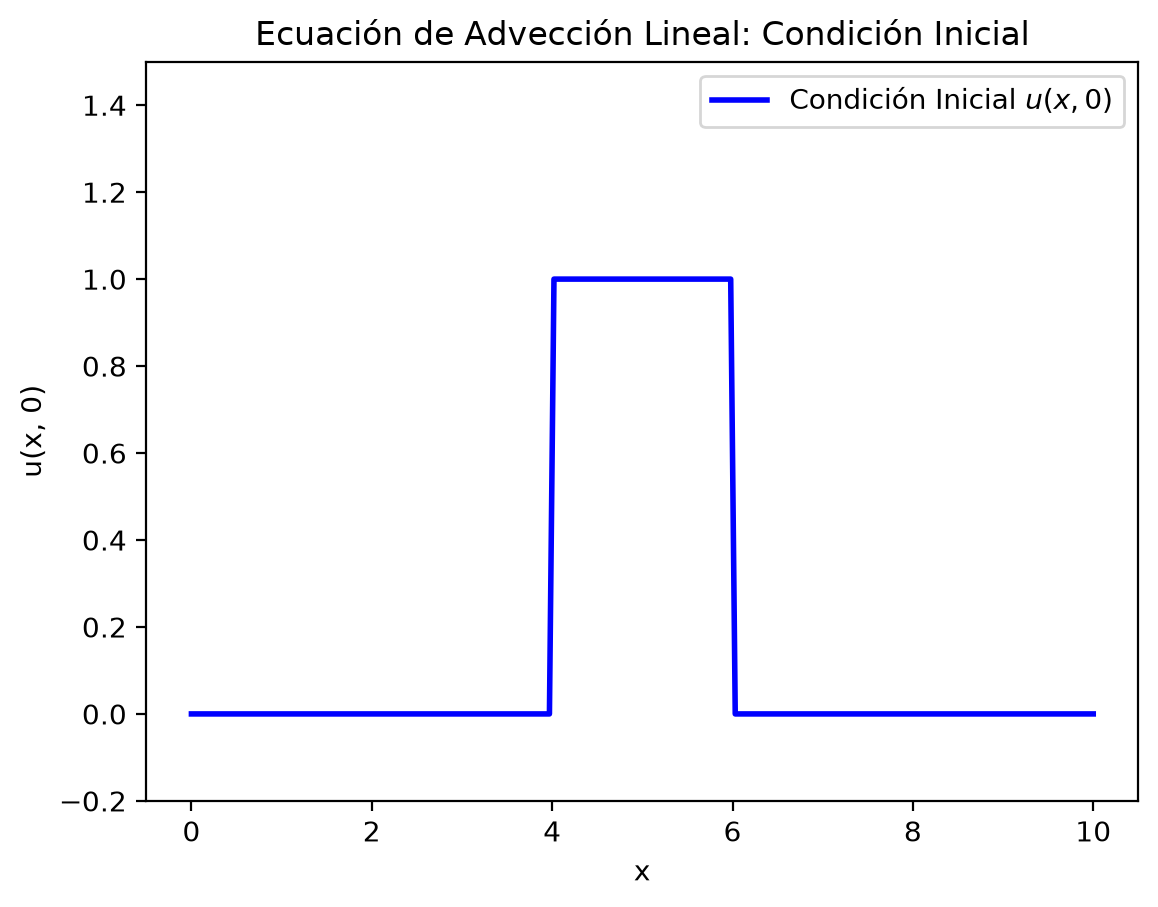

 dx: 0.050251, la distancia entre x[0] y x[1],
 como linspace hace un 'espaciado' uniforme esa disancia
 aplica para todos los x de distnacia 1 entre ellos


In [70]:
# Configuración de estilo para los gráficos (opcional, pero se ve mejor)
# plt.rcParams['figure.figsize'] = (10, 5)
# plt.rcParams['axes.grid'] = True
# plt.rcParams['grid.linestyle'] = '--'
# plt.rcParams['grid.alpha'] = 0.7

# 1. Parámetros físicos y del dominio
L = 10.0      # Longitud del dominio
c = 1.0       # Velocidad de advección
N = 200      # Número de puntos espaciales

# Discretización espacial
x = np.linspace(0, L, N) # genera un arreglo entre 0 y L de tamaño N distribuido de mnaera uniforme 
dx = x[1] - x[0]

# 2. Condición inicial: Perfil cuadrado

# u(x,0) = 1.0 para x en [4.0, 6.0], y 0.0 en el resto
u0 = np.zeros(N)
# Usamos una máscara booleana para asignar 1.0 en el intervalo deseado
mascara = (x >= 4.0) & (x <= 6.0)
u0[mascara] = 1.0

# Graficamos la condición inicial para verificar
plt.plot(x, u0, label='Condición Inicial $u(x,0)$', color='blue', lw=2)
plt.title('Ecuación de Advección Lineal: Condición Inicial')
plt.xlabel('x')
plt.ylabel('u(x, 0)')
plt.ylim(-0.2, 1.5)
plt.legend()
plt.show()

print(f" dx: {dx:.6f}, la distancia entre x[0] y x[1],\n como linspace hace un 'espaciado' uniforme esa disancia\n aplica para todos los x de distnacia 1 entre ellos")

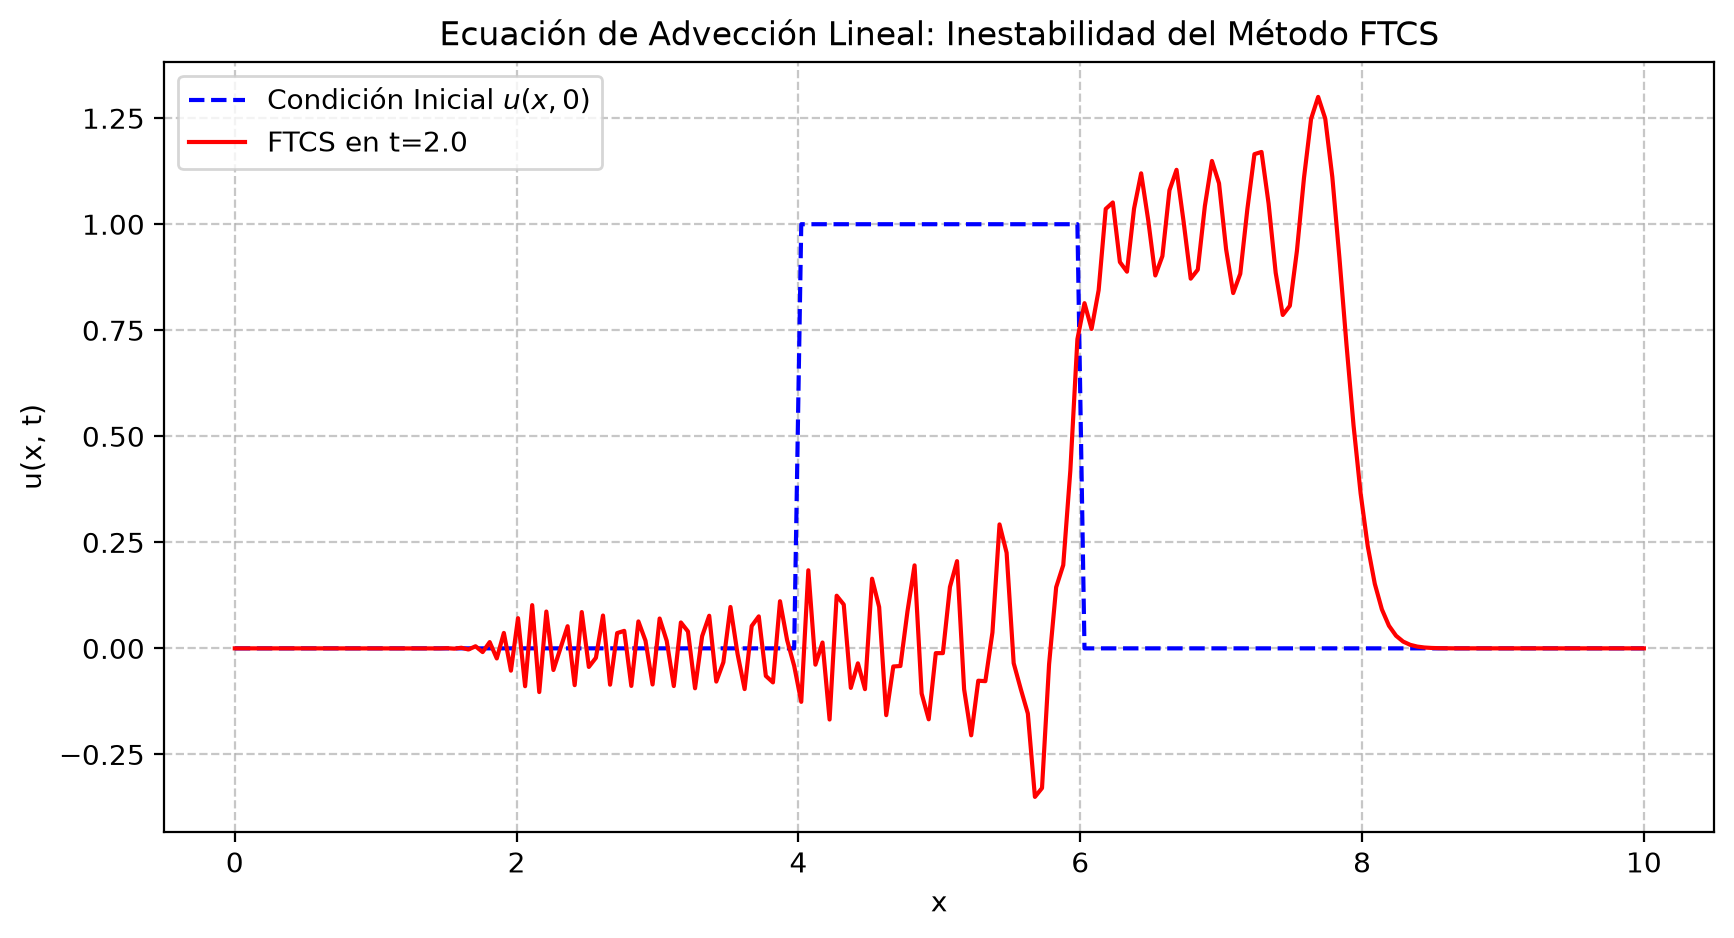

hice la prueba con nu=1 y resulta que ocurre una gran inestabilidad de FTCS mientras más me acerco a nu = 1
 de manera que con nu =0.7 ocurren variaciones de orden de +-8000


In [71]:
# implementando FTCS

# Parámetros temporales para FTCS

"""
nu = c*delta(t)/delta(x)
debido a que no conozo delt(t), 
de manera arbitraria diré que nu = 0.01
como nu < 1 para que funcione bien y queria ver algo distinto a nu = 0.95
resulta ser más inestable a si me acerco más a 1 


espero que cunado entre a la region cuadrada ocurra inestabilidad 
"""

nu = 0.01               # Número de Courant arbitrario para la prueba 0.7? porque es primo
dt = nu * dx / c
t_final = 2.0          # Tiempo corto para observar la inestabilidad antes de que colapse
Nt = int(np.ceil(t_final / dt))

# Bucle de integración FTCS
u_ftcs = u0.copy()
for n in range(Nt):
    # Diferencias finitas centradas en el espacio y hacia adelante en el tiempo
    # np.roll(..., -1) es u_{i+1} y np.roll(..., 1) es u_{i-1} para fronteras periódicas
    u_ftcs = u_ftcs - 0.5 * nu * (np.roll(u_ftcs, -1) - np.roll(u_ftcs, 1))

# Gráfico
plt.figure(figsize=(10, 5))
plt.plot(x, u0, label='Condición Inicial $u(x,0)$', color='blue', linestyle='--')
plt.plot(x, u_ftcs, label=f'FTCS en t={t_final}', color='red')
plt.title('Ecuación de Advección Lineal: Inestabilidad del Método FTCS')
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
print("hice la prueba con nu=1 y resulta que ocurre una gran inestabilidad de FTCS mientras más me acerco a nu = 1\n de manera que con nu =0.7 ocurren variaciones de orden de +-8000")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# 1. Parámetros físicos y temporales
L = 10.0
c = 1.0
Nx = 200
x = np.linspace(0, L, Nx)
dx = x[1] - x[0]

nu = 0.7               # Número de Courant que genera la inestabilidad
dt = nu * dx / c
t_final = 2.0
Nt = int(np.ceil(t_final / dt))

# 2. Inicialización y matriz de historial
u0 = np.zeros(Nx)
u0[(x >= 4.0) & (x <= 6.0)] = 1.0

# Matriz 2D para guardar u(x,t) en cada paso de tiempo
u_history = np.zeros((Nx, Nt))
u_history[:, 0] = u0

# 3. Bucle de integración FTCS
u_ftcs = u0.copy()
for n in range(1, Nt):
    u_ftcs = u_ftcs - 0.5 * nu * (np.roll(u_ftcs, -1) - np.roll(u_ftcs, 1))
    u_history[:, n] = u_ftcs

# 4. Configuración de la animación
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlim(0, L)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel("x")
ax.set_ylabel("u(x, t)")
ax.set_title(rf"Ecuación de Advección: Inestabilidad FTCS ($\nu={nu}$)")
ax.grid(True, linestyle='--', alpha=0.7)

line, = ax.plot([], [], lw=2, color='red', label='FTCS')
# Línea punteada estática para la condición inicial
ax.plot(x, u0, lw=1.5, color='blue', linestyle='--', label='u(x,0)')

time_text = ax.text(0.03, 0.85, '', transform=ax.transAxes, fontsize=12, 
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
ax.legend(loc='upper right')

def init():
    line.set_data([], [])
    time_text.set_text('')
    return line, time_text

# Submuestreo a 75 frames para optimizar rendimiento
frame_indices = np.linspace(0, Nt - 1, 75, dtype=int)

def update(frame_idx):
    current_u = u_history[:, frame_idx]
    line.set_data(x, current_u)
    
    # Ajuste dinámico del eje Y: escala según el error de alta frecuencia
    y_max = max(1.5, np.max(np.abs(current_u)) * 1.1)
    ax.set_ylim(-y_max, y_max)
    
    t_curr = frame_idx * dt
    time_text.set_text(f"$t = {t_curr:.3f}$ s")
    return line, time_text

# blit=False es obligatorio porque ax.set_ylim modifica la caja del gráfico constantemente
ani = animation.FuncAnimation(
    fig, 
    update, 
    frames=frame_indices,
    init_func=init, 
    blit=False, 
    interval=50
)

plt.close(fig)
HTML(ani.to_jshtml())

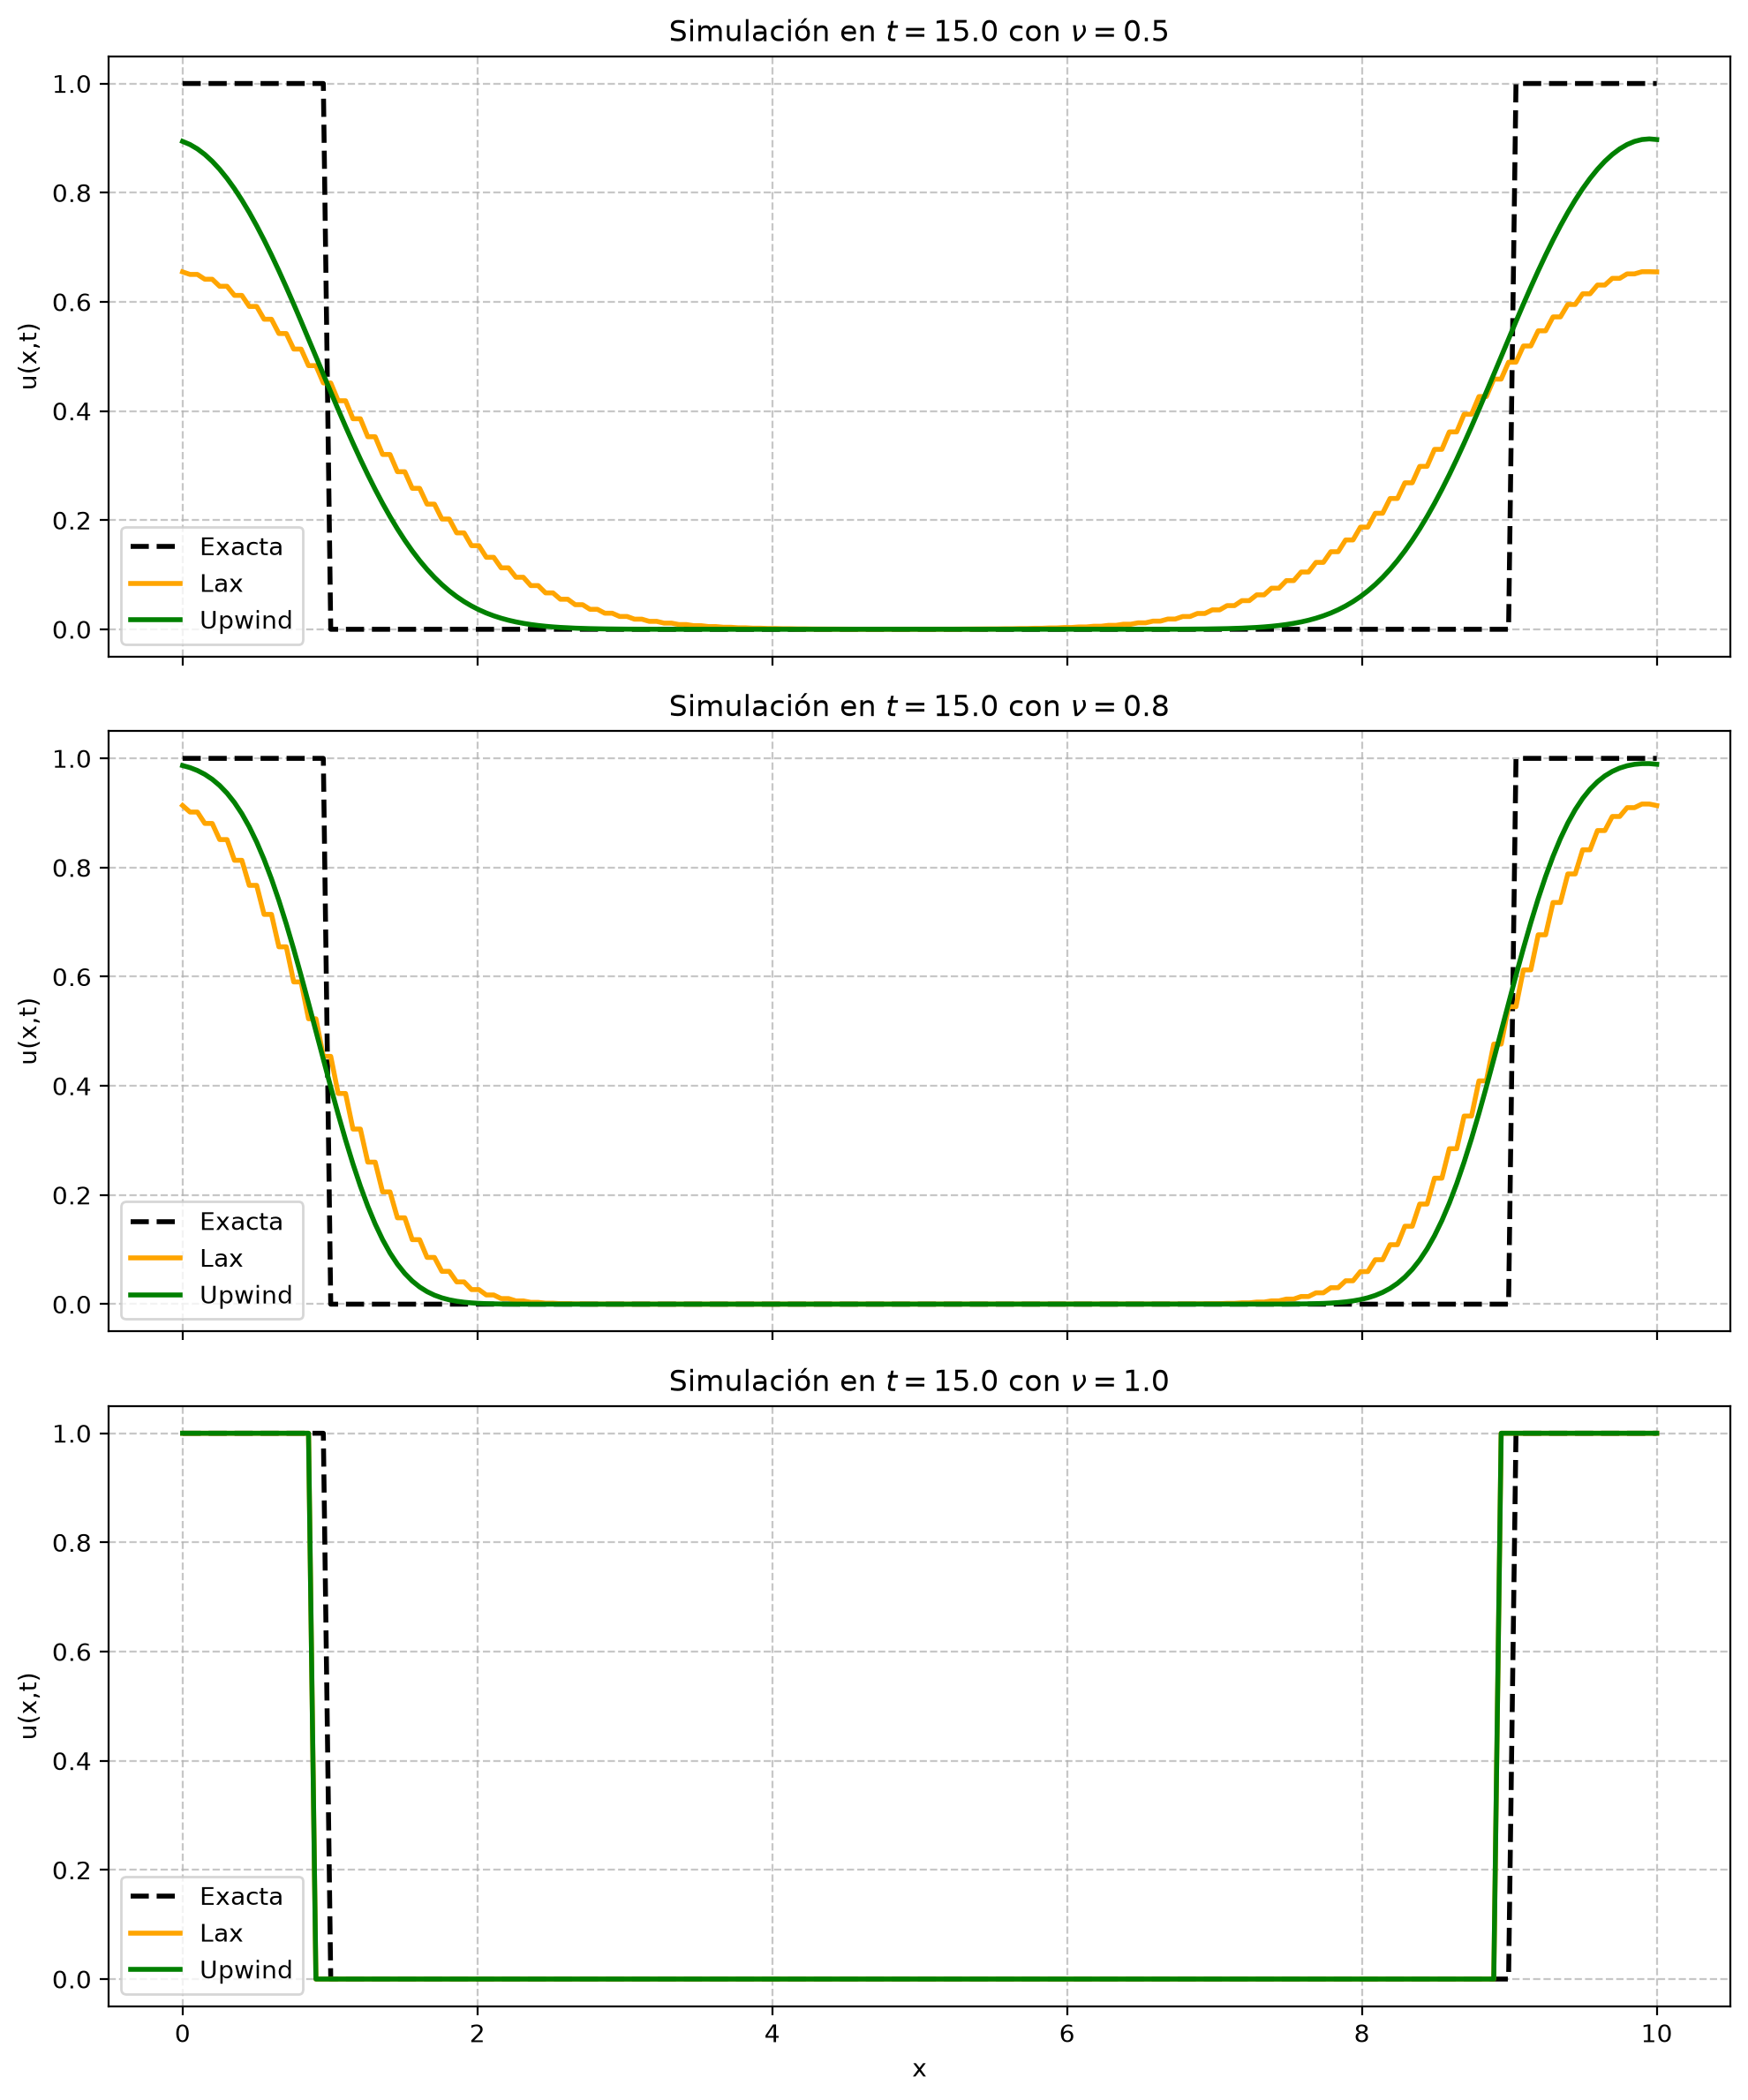

In [72]:
# Valores de Courant a evaluar
nu_values = [0.5, 0.8, 1.0]
t_final = 15.0

# Solución analítica exacta en t = 15.0 (Traslación pura con periodicidad)
x_exact = (x - c * t_final) % L
u_exact = np.zeros(N)
u_exact[(x_exact >= 4.0) & (x_exact <= 6.0)] = 1.0

# Configuración de los gráficos (3 subplots, uno para cada número de Courant)
fig, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

for idx, nu in enumerate(nu_values):
    dt = nu * dx / c
    Nt = int(round(t_final / dt))
    
    # Reiniciamos las condiciones iniciales para cada simulación
    u_lax = u0.copy()
    u_upwind = u0.copy()
    
    # Integración temporal para el valor actual de nu
    for n in range(Nt):
        u_lax_R = np.roll(u_lax, -1)
        u_lax_L = np.roll(u_lax, 1)
        u_upw_C = u_upwind
        u_upw_L = np.roll(u_upwind, 1)
        
        # Esquemas numéricos
        u_lax = 0.5 * (u_lax_R + u_lax_L) - 0.5 * nu * (u_lax_R - u_lax_L)
        u_upwind = u_upw_C - nu * (u_upw_C - u_upw_L)
        
    # Graficamos los resultados
    axs[idx].plot(x, u_exact, label='Exacta', color='black', linestyle='--', lw=2)
    axs[idx].plot(x, u_lax, label='Lax', color='orange', lw=2)
    axs[idx].plot(x, u_upwind, label='Upwind', color='green', lw=2)
    
    axs[idx].set_title(rf'Simulación en $t={t_final}$ con $\nu={nu}$')
    axs[idx].set_ylabel('u(x,t)')
    axs[idx].legend()
    axs[idx].grid(True, linestyle='--', alpha=0.7)

plt.xlabel('x')
plt.tight_layout()
plt.show()

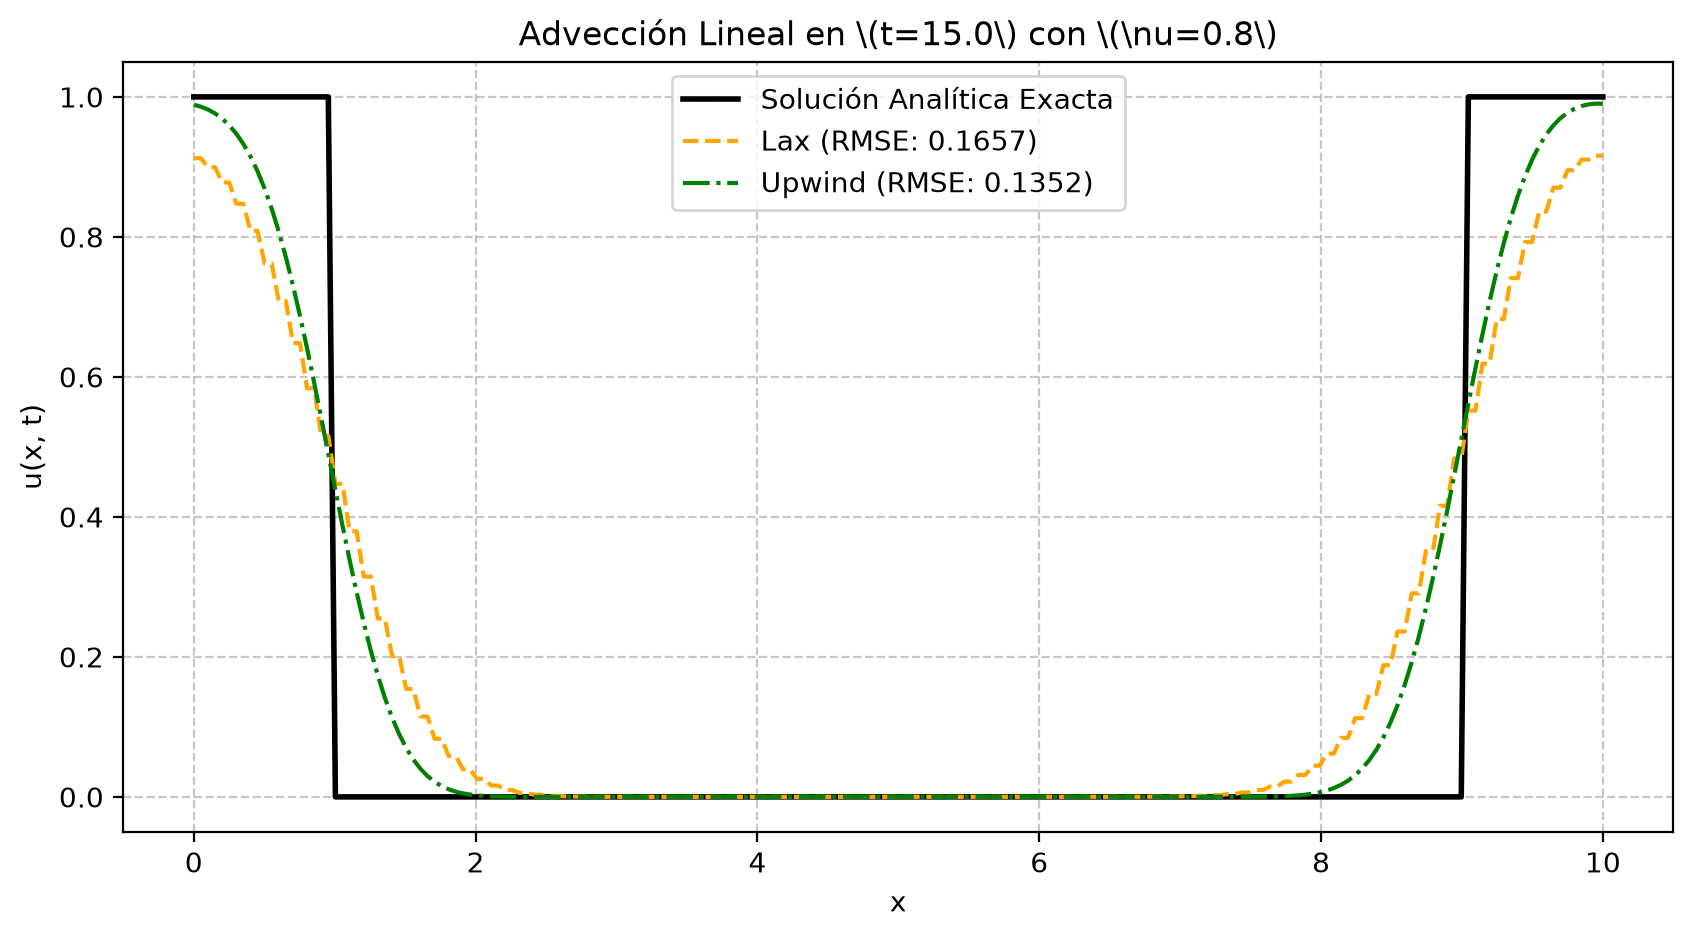

In [79]:
# 2 y 3. Implementación de los métodos de Lax y Upwind, y cálculo analítico

def simular_adveccion(nu, t_final):
    """
    Simula la advección lineal usando los métodos de Lax y Upwind.
    Retorna las soluciones numéricas, la analítica y sus errores RMSE.
    """
    dt = nu * dx / c
    Nt = int(np.ceil(t_final / dt))
    
    # Inicializar arreglos con la condición inicial u0
    u_lax = u0.copy()
    u_upwind = u0.copy()
    
    # Integración temporal
    for n in range(Nt):
        # Método de Lax
        u_lax = 0.5 * (np.roll(u_lax, -1) + np.roll(u_lax, 1)) - 0.5 * nu * (np.roll(u_lax, -1) - np.roll(u_lax, 1))
        
        # Método Upwind (como c > 0, tomamos la diferencia hacia atrás)
        u_upwind = u_upwind - nu * (u_upwind - np.roll(u_upwind, 1))
        
    # Solución Analítica Exacta
    # Como la velocidad es c=1 y el dominio es periódico [0, L], 
    # la onda simplemente se desplaza. Usamos el módulo para la periodicidad.
    x_desplazado = (x - c * t_final) % L
    u_analitica = np.zeros(N)
    mascara_analitica = (x_desplazado >= 4.0) & (x_desplazado <= 6.0)
    u_analitica[mascara_analitica] = 1.0
    
    # Cálculo del Error Cuadrático Medio (RMSE)
    rmse_lax = np.sqrt(np.mean((u_lax - u_analitica)**2))
    rmse_upwind = np.sqrt(np.mean((u_upwind - u_analitica)**2))
    
    return u_lax, u_upwind, u_analitica, rmse_lax, rmse_upwind

# Ejecución para nu = 0.8 y t = 15.0
nu_prueba = 0.8
t_simulacion = 15.0

u_lax, u_upwind, u_analitica, err_lax, err_upwind = simular_adveccion(nu_prueba, t_simulacion)

# Gráfico
plt.figure(figsize=(10, 5))
plt.plot(x, u_analitica, label='Solución Analítica Exacta', color='black', linestyle='-', linewidth=2)
plt.plot(x, u_lax, label=f'Lax (RMSE: {err_lax:.4f})', color='orange', linestyle='--')
plt.plot(x, u_upwind, label=f'Upwind (RMSE: {err_upwind:.4f})', color='green', linestyle='-.')

plt.title(rf'Advección Lineal en \(t={t_simulacion}\) con \(\nu={nu_prueba}\)')
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 2 y 3

Error RMSE Lax (nu=0.8): 0.1681
Error RMSE Upwind (nu=0.8): 0.1385


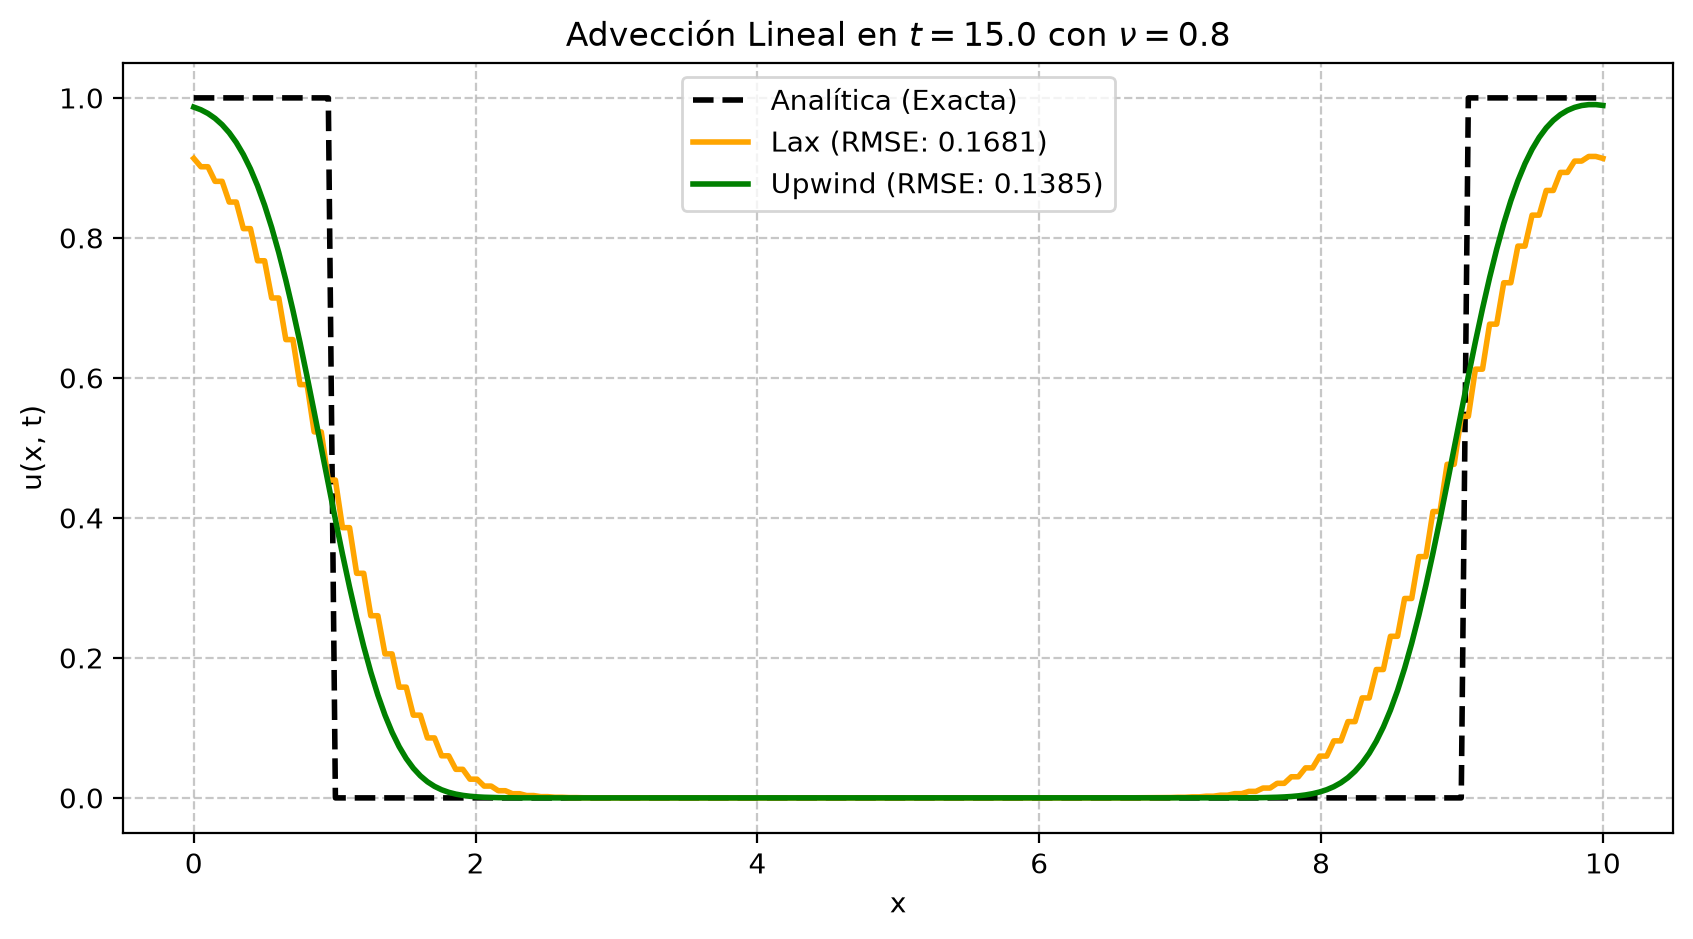

In [ ]:
# Parámetros para Lax y Upwind
nu = 0.8
t_final = 15.0
dt = nu * dx / c
Nt = int(round(t_final / dt))

u_lax = u0.copy()
u_upwind = u0.copy()

# Integración temporal hasta t=15.0
for n in range(Nt):
    # Fronteras periódicas vectorizadas
    u_lax_R = np.roll(u_lax, -1) # u_{i+1}
    u_lax_L = np.roll(u_lax, 1)  # u_{i-1}
    u_upw_L = np.roll(u_upwind, 1) # u_{i-1} para diferencias hacia atrás (c > 0)
    
    # Esquema de Lax
    u_lax = 0.5 * (u_lax_R + u_lax_L) - 0.5 * nu * (u_lax_R - u_lax_L)
    
    # Esquema Upwind
    u_upwind = u_upwind - nu * (u_upwind - u_upw_L)

# Solución analítica exacta (traslación pura con periodicidad)
x_exact = (x - c * t_final) % L
u_exact = np.zeros(N)
u_exact[(x_exact >= 4.0) & (x_exact <= 6.0)] = 1.0

# Cálculo del error (Raíz del Error Cuadrático Medio - RMSE)
error_lax = np.sqrt(np.mean((u_lax - u_exact)**2))
error_upwind = np.sqrt(np.mean((u_upwind - u_exact)**2))

print(f"Error RMSE Lax (nu=0.8): {error_lax:.4f}")
print(f"Error RMSE Upwind (nu=0.8): {error_upwind:.4f}")

# Gráfico superpuesto
plt.figure(figsize=(10, 5))
plt.plot(x, u_exact, label='Analítica (Exacta)', color='black', linestyle='--', lw=2)
plt.plot(x, u_lax, label=f'Lax (RMSE: {error_lax:.4f})', color='orange', lw=2)
plt.plot(x, u_upwind, label=f'Upwind (RMSE: {error_upwind:.4f})', color='green', lw=2)

plt.title(r'Advección Lineal en $t=15.0$ con $\nu=0.8$')
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 4

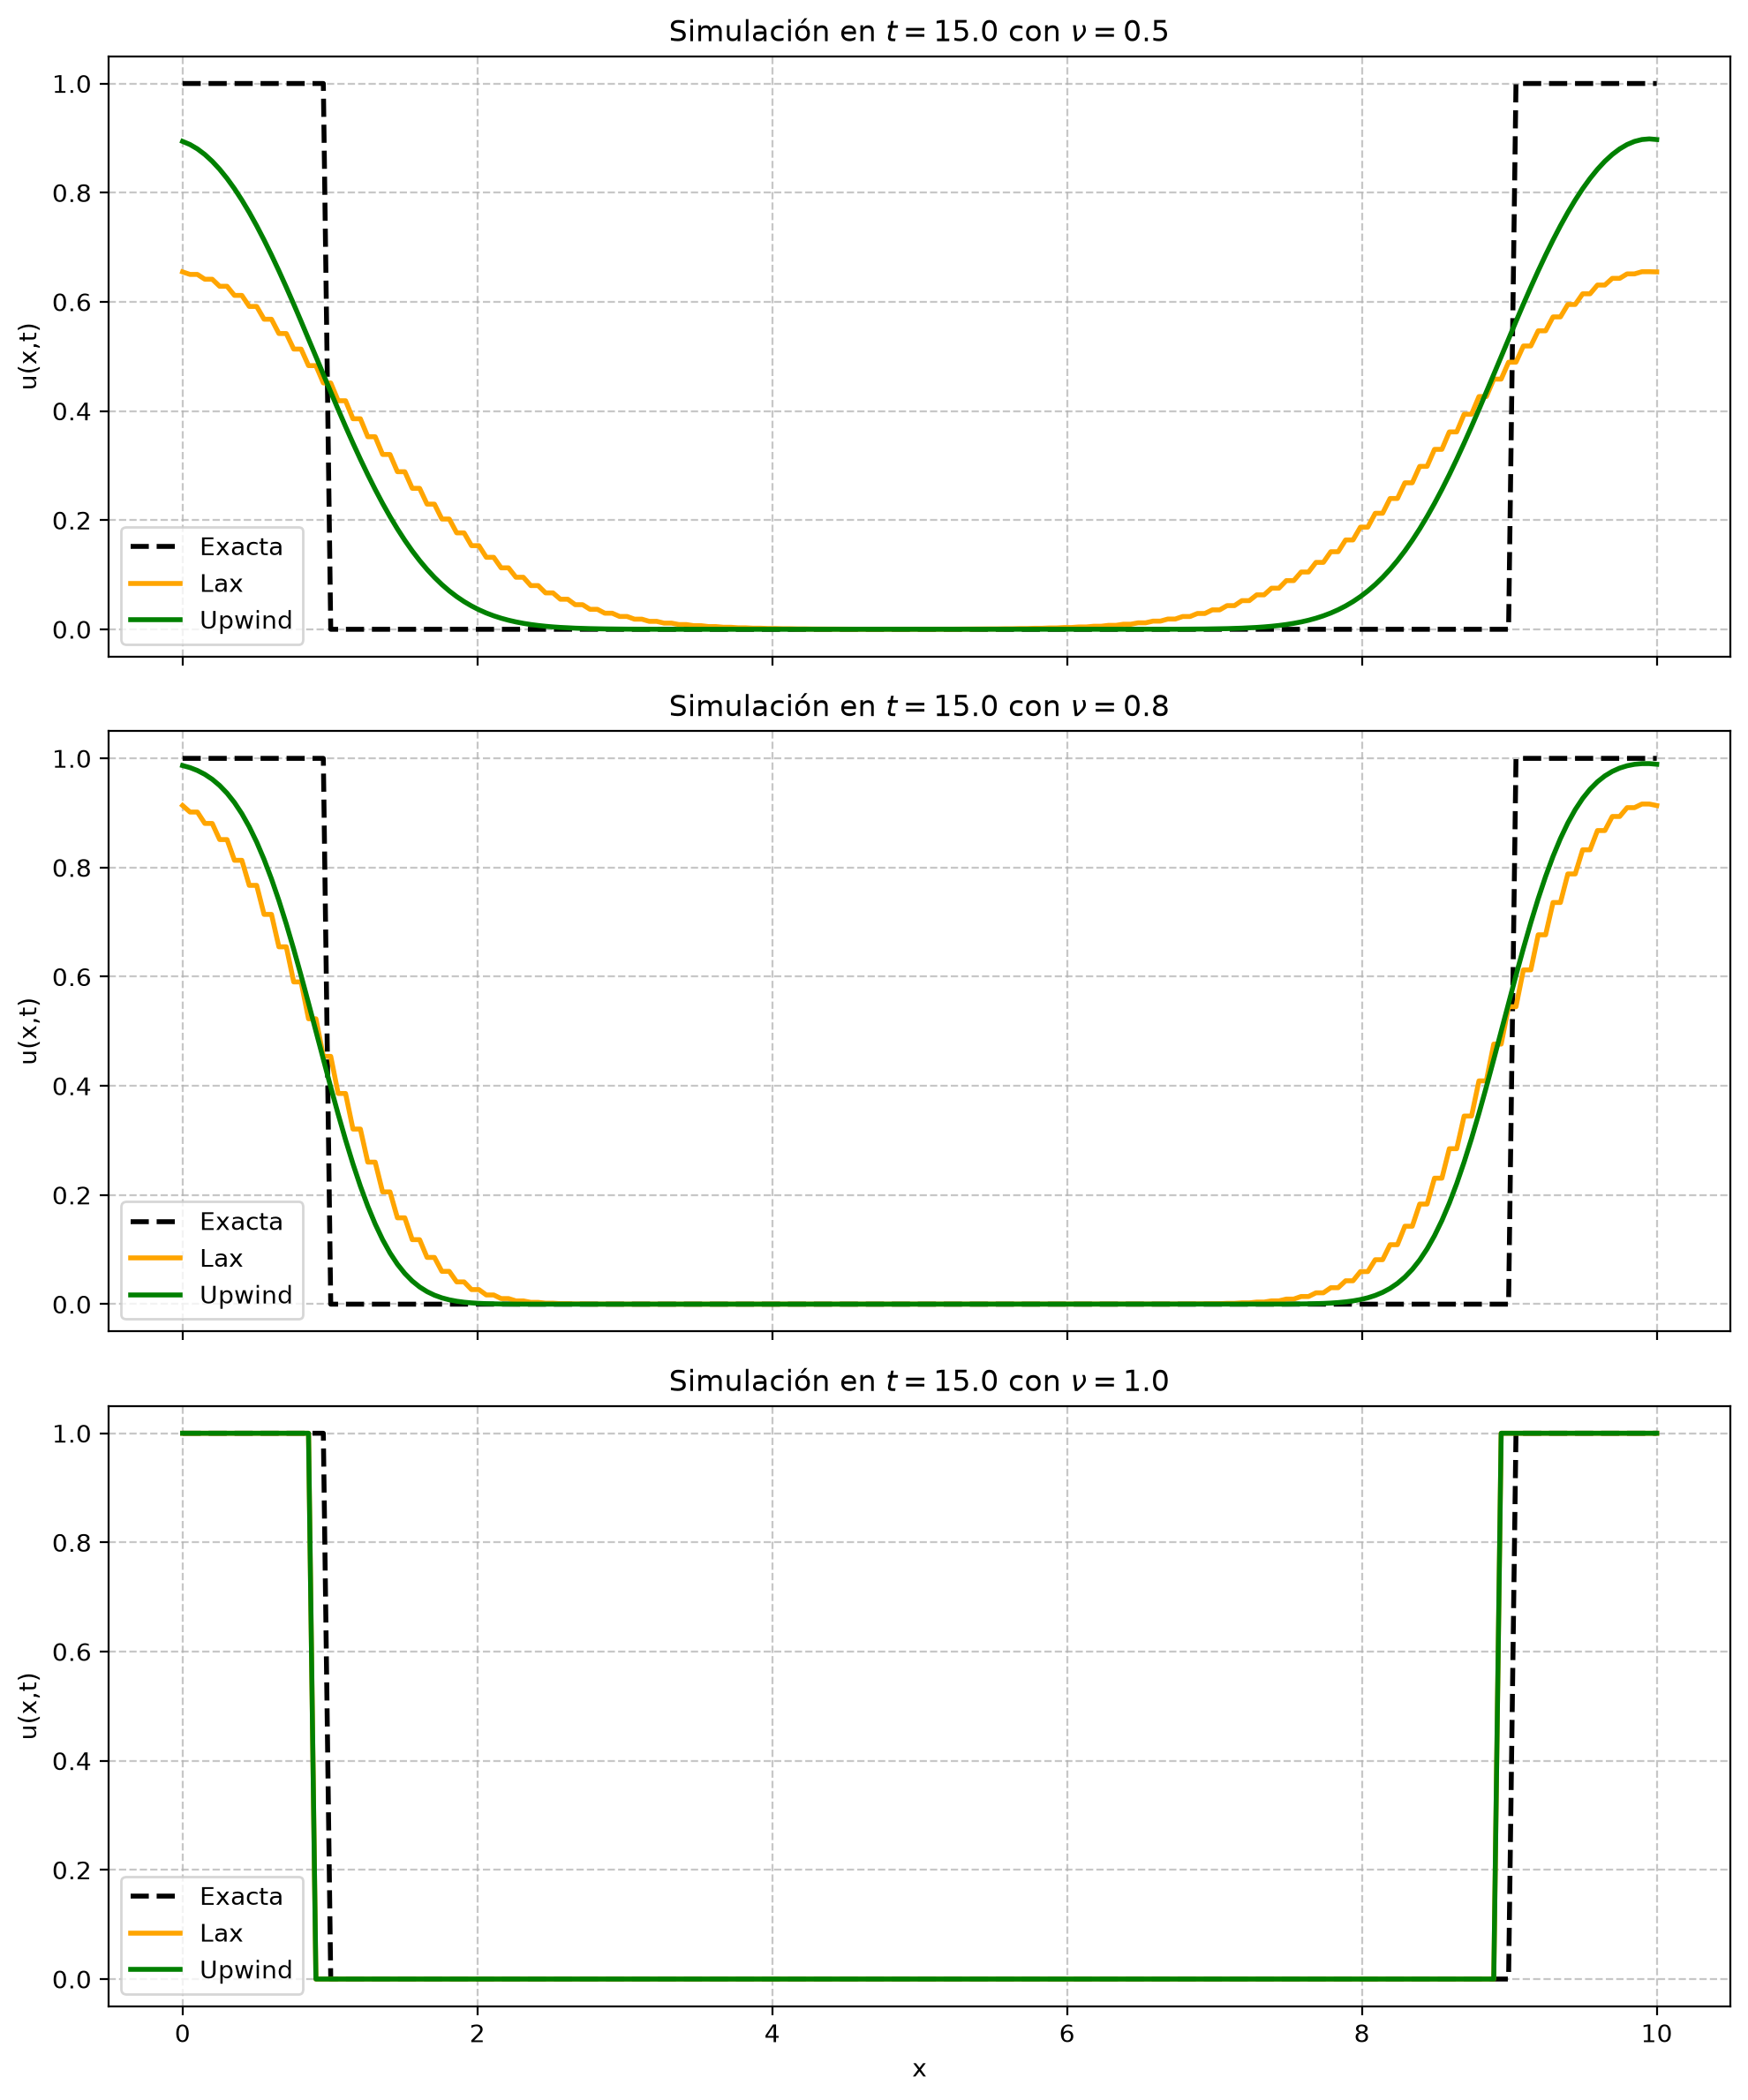

In [ ]:
# Variación del número de Courant
nu_values = [0.5, 0.8, 1.0]

fig, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

for idx, nu_val in enumerate(nu_values):
    dt_val = nu_val * dx / c
    Nt_val = int(round(t_final / dt_val))
    
    u_lax_val = u0.copy()
    u_upwind_val = u0.copy()
    
    for n in range(Nt_val):
        u_lax_val = 0.5 * (np.roll(u_lax_val, -1) + np.roll(u_lax_val, 1)) - 0.5 * nu_val * (np.roll(u_lax_val, -1) - np.roll(u_lax_val, 1))
        u_upwind_val = u_upwind_val - nu_val * (u_upwind_val - np.roll(u_upwind_val, 1))
        
    axs[idx].plot(x, u_exact, label='Exacta', color='black', linestyle='--', lw=2)
    axs[idx].plot(x, u_lax_val, label='Lax', color='orange', lw=2)
    axs[idx].plot(x, u_upwind_val, label='Upwind', color='green', lw=2)
    
    axs[idx].set_title(rf'Simulación en $t=15.0$ con $\nu={nu_val}$')
    axs[idx].set_ylabel('u(x,t)')
    axs[idx].legend()
    axs[idx].grid(True, linestyle='--', alpha=0.7)

plt.xlabel('x')
plt.tight_layout()
plt.show()

# parte no lineal

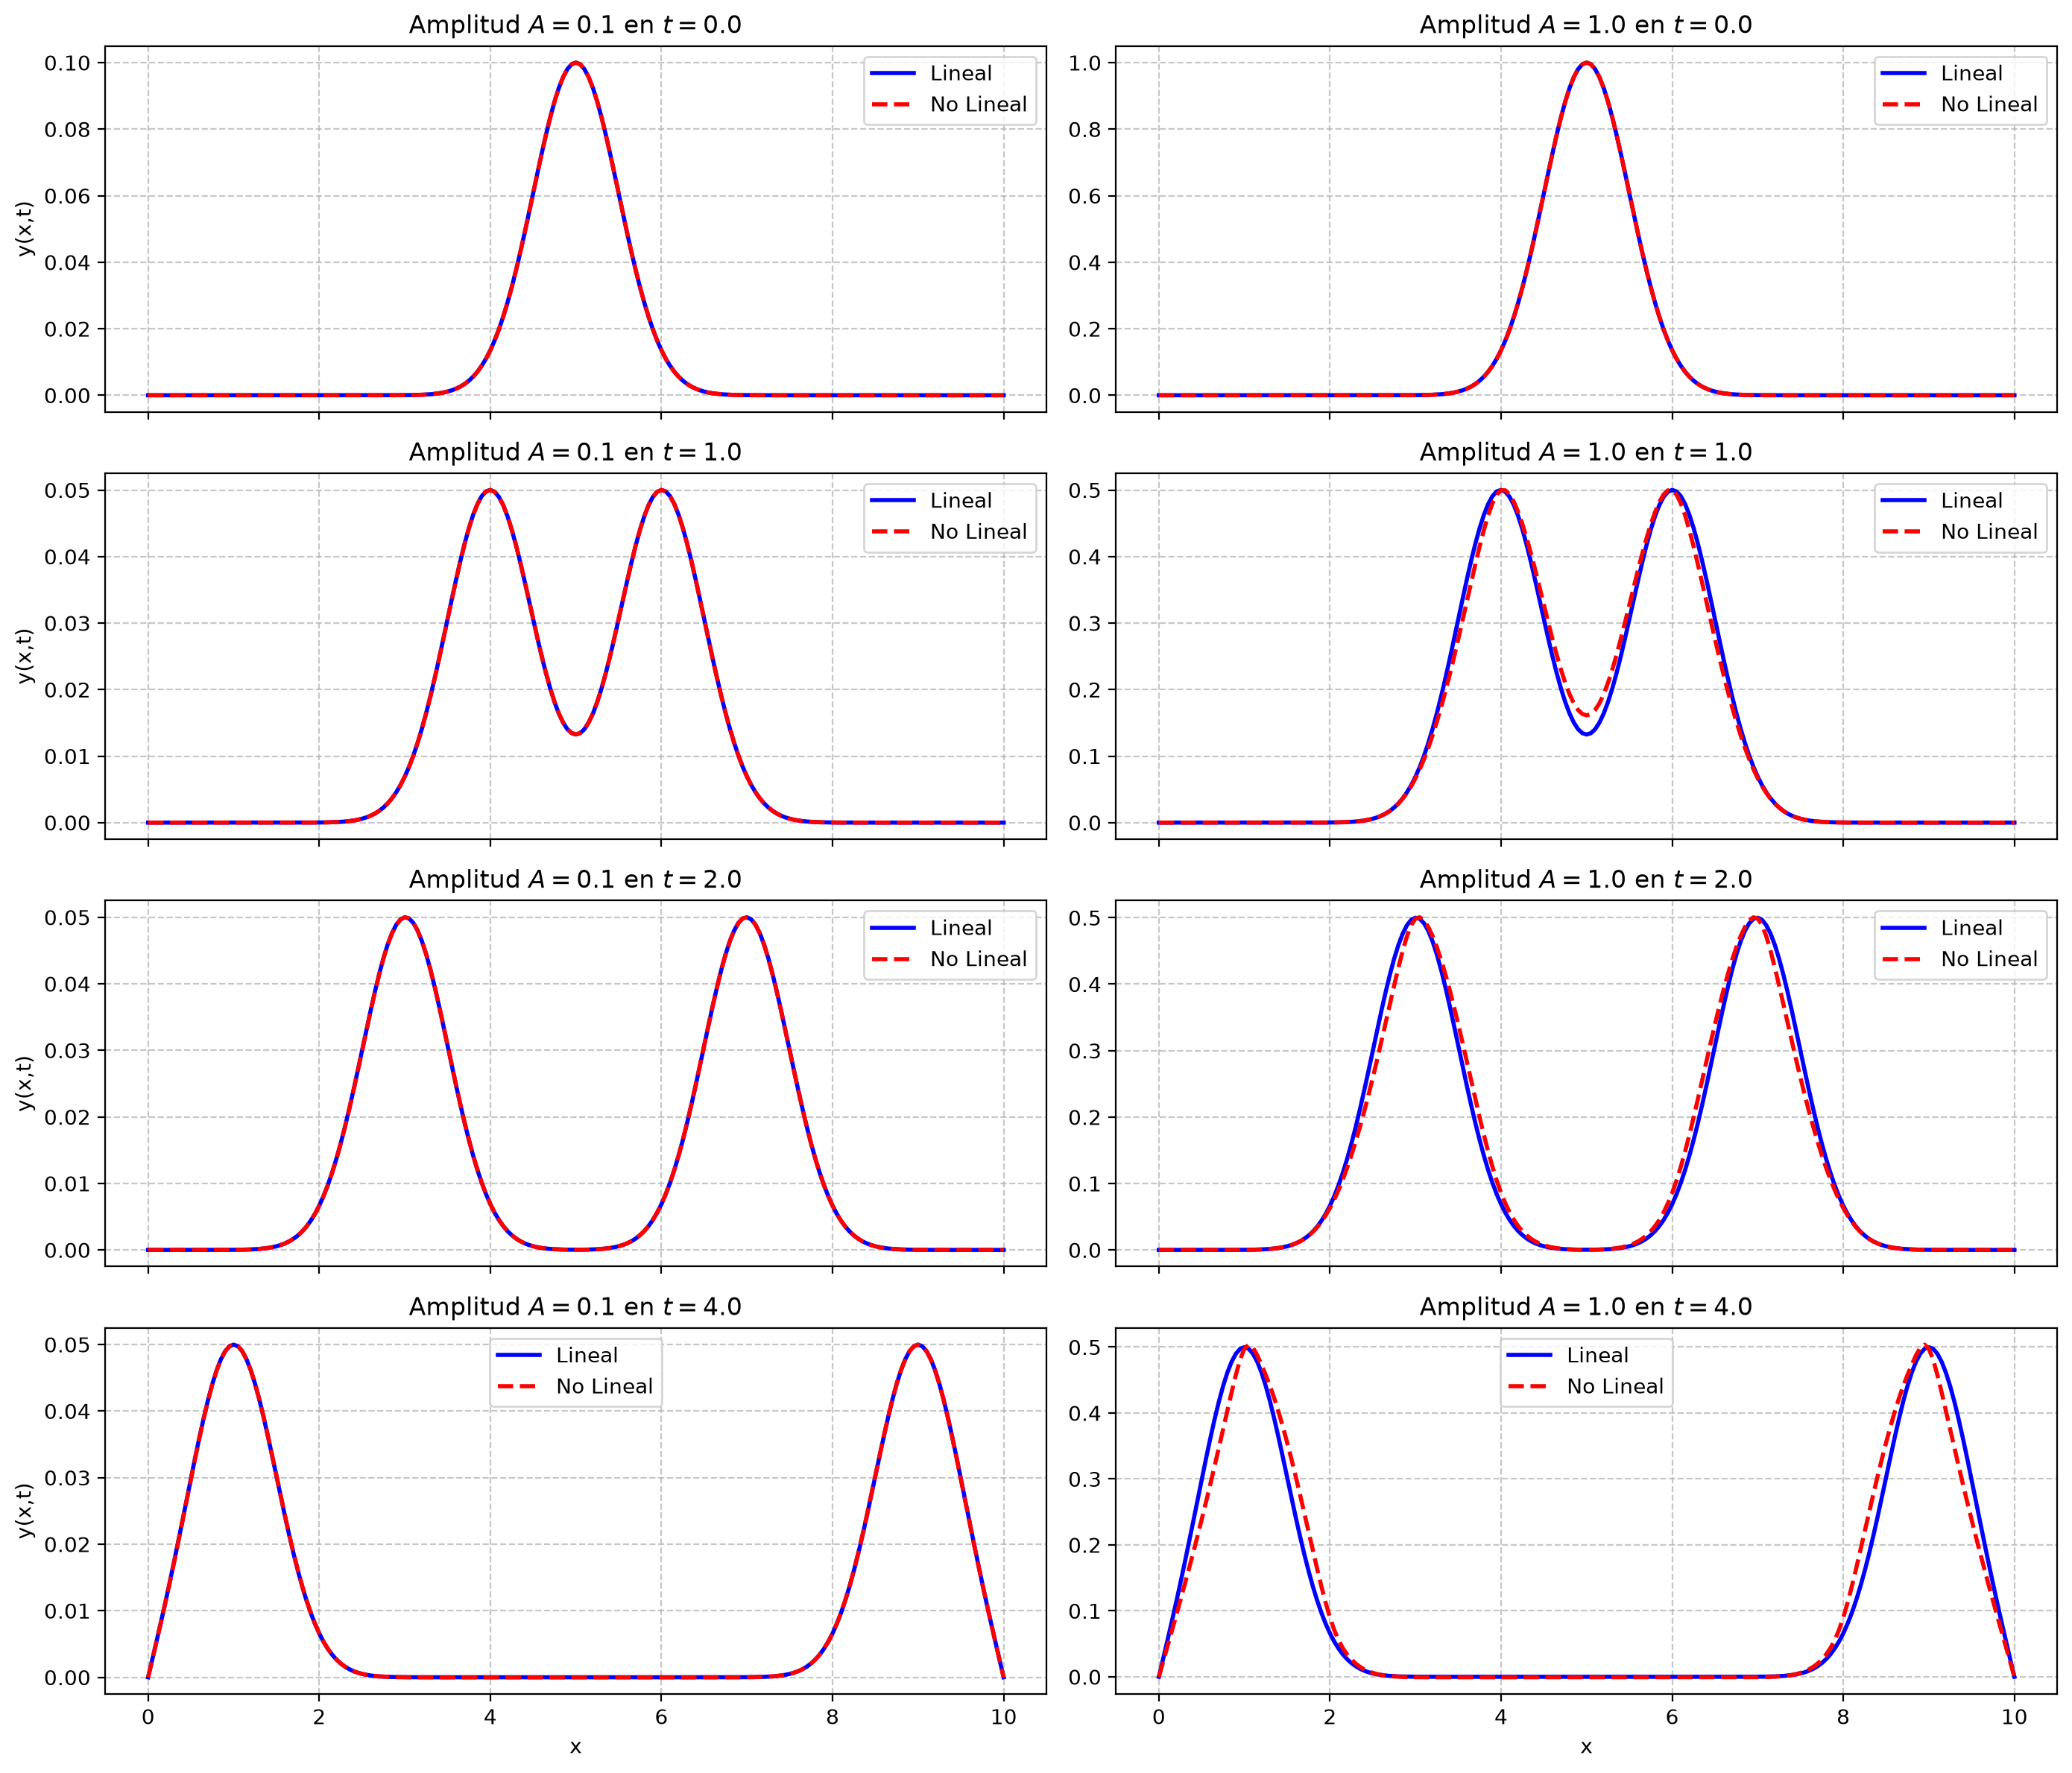

In [ ]:

# 1 y 2. Parámetros y Dominio
L = 10.0
c = 1.0
sigma = 0.5
Nx = 201  # Usamos 201 para tener un nodo central exacto en L/2
x = np.linspace(0, L, Nx)
dx = x[1] - x[0]

# Número de Courant conservador y paso temporal
nu = 0.3
dt = nu * dx / c
t_final = 8.0 # Tiempo suficiente para que la onda viaje y rebote
Nt = int(np.ceil(t_final / dt))

def simular_cuerdas(A, Nt, Nx, nu, dx):
    """
    Simula simultáneamente la cuerda lineal y no lineal para una amplitud A dada.
    Retorna las matrices de evolución temporal y_lin y y_nl.
    """
    # Matrices para almacenar la historia: [espacio, tiempo]
    y_lin = np.zeros((Nx, Nt))
    y_nl = np.zeros((Nx, Nt))
    
    # Condición Inicial (Gaussiana) y extremos fijos (Dirichlet)
    y0 = A * np.exp(-((x - L/2)**2) / (2 * sigma**2))
    y0[0] = 0.0
    y0[-1] = 0.0
    
    y_lin[:, 0] = y0
    y_nl[:, 0] = y0
    
    # Primer paso temporal (velocidad inicial cero -> reposo)
    # Ecuación Lineal
    y_lin[1:-1, 1] = y_lin[1:-1, 0] + 0.5 * (nu**2) * (y_lin[2:, 0] - 2.0 * y_lin[1:-1, 0] + y_lin[:-2, 0])
    
    # Ecuación No Lineal
    dy_dx_0 = (y_nl[2:, 0] - y_nl[:-2, 0]) / (2 * dx)
    factor_nl_0 = (1 + dy_dx_0**2)**(-0.5)
    y_nl[1:-1, 1] = y_nl[1:-1, 0] + 0.5 * (nu**2) * factor_nl_0 * (y_nl[2:, 0] - 2.0 * y_nl[1:-1, 0] + y_nl[:-2, 0])
    
    # Bucle de integración temporal (Esquema centrado explícito de 3 niveles)
    for n in range(1, Nt - 1):
        # Lineal
        y_lin[1:-1, n+1] = 2.0 * y_lin[1:-1, n] - y_lin[1:-1, n-1] + \
                           (nu**2) * (y_lin[2:, n] - 2.0 * y_lin[1:-1, n] + y_lin[:-2, n])
        
        # No Lineal (Calculamos el factor usando la derivada espacial en el paso n)
        dy_dx_n = (y_nl[2:, n] - y_nl[:-2, n]) / (2 * dx)
        factor_nl_n = (1 + dy_dx_n**2)**(-0.5)
        
        y_nl[1:-1, n+1] = 2.0 * y_nl[1:-1, n] - y_nl[1:-1, n-1] + \
                          (nu**2) * factor_nl_n * (y_nl[2:, n] - 2.0 * y_nl[1:-1, n] + y_nl[:-2, n])
        
        # Aseguramos Dirichlet (ya están en cero al crear np.zeros, pero es buena práctica)
        # y_lin[0, n+1] = y_lin[-1, n+1] = 0.0
        # y_nl[0, n+1] = y_nl[-1, n+1] = 0.0
        
    return y_lin, y_nl

# Tiempos específicos para analizar la evolución
tiempos_plot = [0.0, 1.0, 2.0, 4.0]
# Calculamos los índices del arreglo que corresponden a esos tiempos
indices_t = [int(round(t / dt)) for t in tiempos_plot]

# Ejecutamos las simulaciones para A=0.1 y A=1.0
y_lin_01, y_nl_01 = simular_cuerdas(A=0.1, Nt=Nt, Nx=Nx, nu=nu, dx=dx)
y_lin_10, y_nl_10 = simular_cuerdas(A=1.0, Nt=Nt, Nx=Nx, nu=nu, dx=dx)

# Configuramos una grilla de gráficos de 4 filas (tiempos) x 2 columnas (Amplitudes)
fig, axs = plt.subplots(4, 2, figsize=(14, 12), sharex=True)

for i, (t_val, idx) in enumerate(zip(tiempos_plot, indices_t)):
    # Columna 1: A = 0.1
    axs[i, 0].plot(x, y_lin_01[:, idx], label='Lineal', color='blue', lw=2)
    axs[i, 0].plot(x, y_nl_01[:, idx], label='No Lineal', color='red', linestyle='--', lw=2)
    axs[i, 0].set_title(rf'Amplitud $A=0.1$ en $t={t_val}$')
    axs[i, 0].set_ylabel('y(x,t)')
    axs[i, 0].grid(True, linestyle='--', alpha=0.7)
    axs[i, 0].legend()
    
    # Columna 2: A = 1.0
    axs[i, 1].plot(x, y_lin_10[:, idx], label='Lineal', color='blue', lw=2)
    axs[i, 1].plot(x, y_nl_10[:, idx], label='No Lineal', color='red', linestyle='--', lw=2)
    axs[i, 1].set_title(rf'Amplitud $A=1.0$ en $t={t_val}$')
    axs[i, 1].grid(True, linestyle='--', alpha=0.7)
    axs[i, 1].legend()

axs[3, 0].set_xlabel('x')
axs[3, 1].set_xlabel('x')
plt.tight_layout()
plt.show()


### 1. Ecuación de Advección Lineal: Inestabilidad del Esquema FTCS

**Análisis Teórico y Observación**

* **Observación de la simulación:** Al ejecutar el esquema numérico FTCS, la solución desarrolla oscilaciones extremas (ruido de alta frecuencia) que destruyen por completo el perfil cuadrado inicial de la onda. Si la simulación avanza en el tiempo, los valores crecen exponencialmente produciendo un desbordamiento numérico (`overflow`).


* **Análisis del Factor de Amplificación (Von Neumann):** Al sustituir un modo de Fourier discreto en el esquema numérico, se obtiene un factor de amplificación $G = 1 - i \nu \sin(k \Delta x)$. Para que un método explícito sea numéricamente estable, se requiere $\vert{}G\vert{} \le 1$. Calculando el módulo al cuadrado se obtiene $\vert{}G\vert{}^2 = 1 + \nu^2 \sin^2(k \Delta x)$. Dado que el término $\nu^2 \sin^2(k \Delta x)$ es estrictamente mayor que cero para cualquier modo espacial ($k \neq 0$), se concluye que $\vert{}G\vert{} > 1$ en todo momento. Esto demuestra que el esquema FTCS es incondicionalmente inestable para la ecuación de advección pura; cualquier error de truncamiento se amplifica exponencialmente.



---

### 2. Ecuación de Advección Lineal: Métodos de Lax y Upwind

**Análisis Numérico y Comparación de Esquemas**

* **Método de Lax (Difusión Numérica):** Para lograr la estabilidad, el método de Lax introduce un término de difusión numérica (viscosidad artificial) en la ecuación original. La magnitud de esta disipación es proporcional a $(1 - \nu^2)$. Cuando $\nu = 0.5$, la difusión es máxima, achatando y esparciendo severamente la onda cuadrada. Al aumentar a $\nu = 0.8$, la disipación se reduce, pero sigue deformando las esquinas del pulso.


* **Método Upwind (Sentido Causal):** El esquema Upwind mantiene el sentido causal de la onda tomando información "aguas arriba" (en este caso, del nodo $i-1$ ya que $c>0$). Su término disipativo es proporcional a $(1 - \nu)$. Por esto, para $\nu = 0.5$ y $\nu = 0.8$, Upwind preserva de forma significativamente superior la amplitud y la forma rectangular del pulso frente al método de Lax. Esto se comprueba cuantitativamente al observar un menor error RMSE.


* **El caso óptimo $\nu = 1.0$:** Cuando $\nu = 1.0$, los términos de viscosidad artificial de ambos métodos se anulan. Esto se conoce como el "número de Courant mágico" para advección pura: la información se traslada exactamente un nodo $\Delta x$ por cada paso $\Delta t$, logrando que la solución discreta coincida a la perfección con la analítica.



---

### 3. Ecuación de Advección No Lineal: Dinámica de la Cuerda

**Análisis Físico y Explicación de la Deformación**

* **Efecto de la amplitud ($A$):** Para amplitudes pequeñas ($A=0.1$), el término no lineal es despreciable, por lo que las soluciones del modelo lineal y no lineal se superponen casi perfectamente en todo momento. Para amplitudes grandes ($A=1.0$), el término no lineal domina la dinámica y el comportamiento del sistema difiere drásticamente del caso lineal.


* **Evolución temporal ($t$):** La condición inicial gaussiana se divide en dos pulsos que viajan en direcciones opuestas. En el sistema lineal, los pulsos mantienen su simetría gaussiana de forma indefinida. En el sistema no lineal con $A=1.0$, los pulsos pierden su simetría con el paso del tiempo, deformándose estructuralmente a medida que se propagan.


* **Explicación Física de la Deformación:** En la ecuación de onda no lineal, la velocidad de propagación no es constante, sino que depende de una "velocidad efectiva" local $c_{eff} = c [ 1 + (\frac{\partial y}{\partial x})^2 ]^{-1/4}$.


* En la cresta de la onda, la pendiente es nula ($\frac{\partial y}{\partial x} = 0$), por lo que la velocidad local es máxima e igual a $c$.


* En los flancos de la onda, la pendiente es distinta de cero ($\vert{}\frac{\partial y}{\partial x}\vert{} > 0$), lo que hace que el término entre corchetes sea menor que $1$. En consecuencia, los flancos viajan a una velocidad menor que la cresta ($c_{eff} < c$).


* Físicamente, esto significa que la cresta de la onda avanza más rápido que la base. Como resultado, la parte superior "alcanza" a la parte inferior delantera, provocando que la onda se incline y se empine asimétricamente hacia adelante (un fenómeno análogo a cómo rompen las olas en la costa).

https://github.com/troncos22/Fisica_computacional_-_metodos_numericos/tree/main/tareas

# Apratado de IA

- verifica si la explicación es clara
- verifica si los gráficos son claros
- qué más podrías agregar al análisis 
    - análisis de
- ayudame a pasar esta parte de python a c++
    - trouble shooting de c++